## <mark>**WITH 92 IMAGES, IMPROVEMENTS MADE TO TEXTURE.PY**</mark>

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", message=".*encountered in matmul.*", category=RuntimeWarning)

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline



## correlation analysis (heatmap)

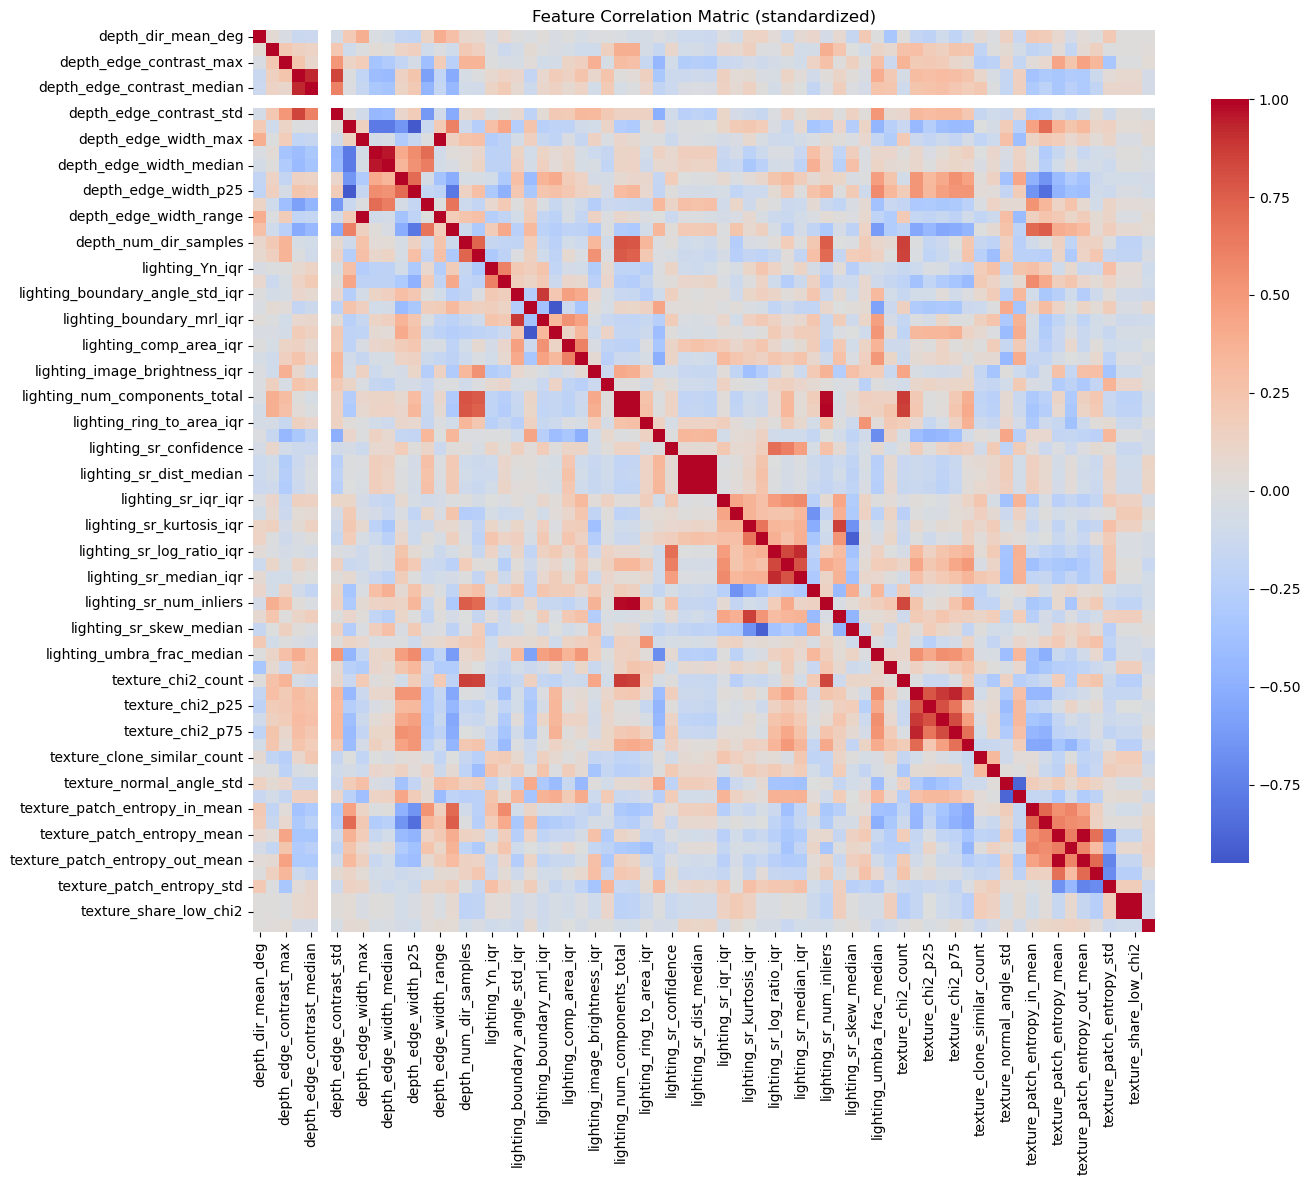


Top correlations with LABEL:

lighting_sr_log_ratio_spread      -0.146425
texture_patch_entropy_min          0.139044
texture_clone_similar_count       -0.128704
lighting_umbra_frac_median        -0.128411
texture_patch_entropy_std         -0.127479
lighting_sr_dist_p75               0.118807
lighting_sr_dist_mean              0.116807
texture_patch_entropy_out_mean     0.115288
texture_patch_entropy_mean         0.113298
lighting_boundary_angle_std_iqr   -0.107392
lighting_sr_dist_median            0.105816
texture_patch_entropy_max          0.104159
lighting_Yn_iqr                   -0.100748
texture_share_high_chi2           -0.098281
texture_share_low_chi2            -0.098281
lighting_boundary_mrl_iqr         -0.097891
lighting_usable_frac              -0.095069
texture_normal_mrl                -0.093775
depth_num_dir_samples             -0.086315
lighting_sr_num_inliers           -0.086262
Name: label, dtype: float64


In [54]:
# load data
path = "features_2.csv"

df = pd.read_csv(path)

# keep numeric columns
df_num = df.select_dtypes(include=[np.number])

assert "label" in df_num.columns, "Label column not found"

# standardize features
X = df_num.drop(columns=["label"])
y = df_num["label"]

X_std = (X - X.mean()) / (X.std() + 1e-8)

df_std = X_std.copy()
df_std["label"] = y.values

# correlation matrix
corr = df_std.corr(method="pearson")

# heatmap
plt.figure(figsize=(14,12))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Feature Correlation Matric (standardized)")
plt.tight_layout()
plt.show()

# sorted feature-label correlation
label_corr = corr["label"].drop("label").sort_values(key=np.abs, ascending=False)

print("\nTop correlations with LABEL:\n")
print(label_corr.head(20))

## logistic weights

In [55]:
# load data
CSV_PATH = "features_2.csv"

df = pd.read_csv(CSV_PATH)
df = df.select_dtypes(include=[np.number])

assert "label" in df.columns, "Label column not found"

X = df.drop(columns=["label"])
y = df["label"].values

feature_names = X.columns.tolist()

# -----------------------------
# standardize features
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Max abs value in X_scaled:", np.max(np.abs(X_scaled)))
print("All finite in X_scaled:", np.isfinite(X_scaled).all())

# -----------------------------
# train logistic regression
# -----------------------------
model = LogisticRegression(
    l1_ratio=1, # this means the penalty used is l1
    solver="liblinear",
    C=0.1,
    max_iter=2000
)

model.fit(X_scaled, y)

# -----------------------------
# extract weights and bias
# -----------------------------
weights = model.coef_[0]
bias = model.intercept_[0]

# combine into table
coef_df = pd.DataFrame({
    "feature": feature_names,
    "weight": weights,
    "abs_weight": np.abs(weights)
}).sort_values("abs_weight", ascending=False)

print("\n==============================")
print("LOGISTIC REGRESSION RESULTS")
print("==============================")
print(f"\nBias (intercept): {bias:.4f}")
print("\nTop 25 Features by |Weight|:\n")
print(coef_df.head(25))

# save full table
coef_df.to_csv("logistic_weights.csv", index=False)

# -----------------------------
# cross-validation accuracy
# -----------------------------
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accs = []
fold_num = 1

for train_idx, test_idx in kf.split(X_scaled, y):
    X_tr, X_te = X_scaled[train_idx], X_scaled[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    model_cv = LogisticRegression(
        l1_ratio=1,
        solver="liblinear",
        max_iter=1000
    )
    model_cv.fit(X_tr, y_tr)

    w = model_cv.coef_[0]
    b = model_cv.intercept_[0]

    max_abs_w = np.max(np.abs(w))
    print(f"Fold {fold_num}: max|coef| = {max_abs_w:.3e}, intercept = {float(b):.3e}")

    # scores computation MUST be inside the loop
    scores = X_te @ w + b

    print("  scores all finite?", np.isfinite(scores).all(), " min/max:", np.min(scores), np.max(scores))

    # Debug if scores are non-finite
    if not np.isfinite(scores).all():
        print(f"\n!!! Non-finite scores in fold {fold_num} !!!")
        bad_local = np.where(~np.isfinite(scores))[0]
        print("How many bad test rows:", len(bad_local))
        print("First few bad positions (within fold):", bad_local[:10])
        print("Bad score values:", scores[bad_local[:10]])
        print("All finite in X_te:", np.isfinite(X_te).all())

        # Identify which features are non-finite in those bad rows (if any)
        for j in bad_local[:5]:
            row = X_te[j]
            bad_feat_idx = np.where(~np.isfinite(row))[0]
            if len(bad_feat_idx) > 0:
                bad_feats = [feature_names[k] for k in bad_feat_idx[:10]]
                print(f"Bad features for test-row {j}:", bad_feats)

        # Skip this fold so accuracy doesn't crash
        fold_num += 1
        continue

    preds = model_cv.predict(X_te)
    accs.append(accuracy_score(y_te, preds))

    fold_num += 1

print("\n5-Fold Cross-Validation Accuracy:")
print(f"Mean: {np.mean(accs):.4f}")
print(f"Std : {np.std(accs):.4f}")

Max abs value in X_scaled: 9.516083548165275
All finite in X_scaled: True

LOGISTIC REGRESSION RESULTS

Bias (intercept): 0.0000

Top 25 Features by |Weight|:

                         feature  weight  abs_weight
0             depth_dir_mean_deg     0.0         0.0
44       lighting_sr_num_inliers     0.0         0.0
50            texture_chi2_count     0.0         0.0
49          lighting_usable_frac     0.0         0.0
48    lighting_umbra_frac_median     0.0         0.0
47       lighting_umbra_frac_iqr     0.0         0.0
46       lighting_sr_skew_median     0.0         0.0
45          lighting_sr_skew_iqr     0.0         0.0
43     lighting_sr_median_median     0.0         0.0
35          lighting_sr_dist_p75     0.0         0.0
42        lighting_sr_median_iqr     0.0         0.0
41  lighting_sr_log_ratio_spread     0.0         0.0
40     lighting_sr_log_ratio_iqr     0.0         0.0
39   lighting_sr_kurtosis_median     0.0         0.0
38      lighting_sr_kurtosis_iqr     0.0     

**NOTE**: use penalty l1 (l1_ratio=1) (lasso regression) to automatically select important features by forcing irrelevant feature coefficients to zero (ideal for sparse data with many irrelevant variables) ; use penalty l2 (l2_ratio=0) (ridge regression) to prevent overfitting when all features are relevant as it shrinks coefficients evenly without setting them to zero.

|   feature    |          l1 (lasso)             |         l2 (ridge)         |
| ------------ | ------------------------------- | -------------------------- | 
| coeff impact | sets some to exactly 0 (sparse) | shrinks to near 0 (dense)  |
| main use     | feature selection               | overfitting prevention     |
| best for     | many irrelevant features        | highly correlated features |

## logistics reduced

In [56]:
CSV_PATH = "features_2.csv"
df = pd.read_csv(CSV_PATH)

# -----------------------------
# manually select core features
# -----------------------------
selected_features = [

    # depth (hardness + direction)
    "depth_edge_width_median",
    "depth_edge_width_cv",
    "depth_dir_std_deg",
    #"depth_num_dir_samples",

    # lighting (strength consistency)
    "lighting_sr_log_ratio_iqr",
    "lighting_sr_dist_median",
    #"lighting_Yn_median",
    #"lighting_usable_frac",

    # texture (boundary texture + entropy)
    "texture_chi2_mean",
    #"texture_chi2_std",
    #"texture_normal_mrl",
    "texture_patch_entropy_outlier_frac",
    "texture_clone_similar_count"
]

df = df[selected_features + ["label"]]

X = df.drop(columns=["label"])
y = df["label"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accs = []

for train_idx, test_idx in kf.split(X_scaled, y):
    X_tr, X_te = X_scaled[train_idx], X_scaled[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    model = LogisticRegression(
        l1_ratio=1,
        solver="liblinear",
        max_iter=1000
    )

    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    accs.append(accuracy_score(y_te, preds))

print(df["texture_clone_similar_count"].describe())
print(df[[
    "texture_chi2_mean",
    "texture_patch_entropy_outlier_frac"
]].corr())

print("\nReduced Feature Set CV Accuracy:")
print(f"Mean: {np.mean(accs):.4f}")
print(f"Std : {np.std(accs):.4f}")

count    92.000000
mean      1.358696
std       5.072186
min       0.000000
25%       0.000000
50%       0.000000
75%       1.000000
max      46.000000
Name: texture_clone_similar_count, dtype: float64
                                    texture_chi2_mean  \
texture_chi2_mean                            1.000000   
texture_patch_entropy_outlier_frac           0.009352   

                                    texture_patch_entropy_outlier_frac  
texture_chi2_mean                                             0.009352  
texture_patch_entropy_outlier_frac                            1.000000  

Reduced Feature Set CV Accuracy:
Mean: 0.4117
Std : 0.0930


## grouped

In [57]:
# silence matmul warnings
warnings.filterwarnings("ignore", message=".*encountered in matmul.*", category=RuntimeWarning)

# -----------------------------
# load data
# -----------------------------
CSV_PATH = "features_2.csv"

df = pd.read_csv(CSV_PATH)

assert "label" in df.columns, "Label column not found"
assert "filename" in df.columns, "Filename column not found"

# -----------------------------
# build grouping variable (keep pairs together)
# -----------------------------
groups = (
    df["filename"]
    .str.replace("-edited", "", regex=False)
    .str.replace(".jpg", "", regex=False)
)

# -----------------------------
# keep only numeric for modeling
# -----------------------------
df_num = df.select_dtypes(include=[np.number])

X = df_num.drop(columns=["label"])
y = df_num["label"].values

feature_names = X.columns.tolist()

X_all = X.copy()  # keep all features for RandomForest test

# -----------------------------
# TRYING SINGLE FEATURE MODEL
# -----------------------------
X = X[["texture_chi2_p75"]]   # keep only this feature since it is the 
feature_names = ["texture_chi2_p75"]

# -----------------------------
# standardize features
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Max abs value in X_scaled:", np.max(np.abs(X_scaled)))
print("All finite in X_scaled:", np.isfinite(X_scaled).all())

# -----------------------------
# train logistic regression (full dataset)
# -----------------------------
model = LogisticRegression(
    l1_ratio=1,
    solver="liblinear",
    C=0.1,
    max_iter=2000
)

model.fit(X_scaled, y)

# -----------------------------
# extract weights and bias
# -----------------------------
weights = model.coef_[0]
bias = model.intercept_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "weight": weights,
    "abs_weight": np.abs(weights)
}).sort_values("abs_weight", ascending=False)

print("\n==============================")
print("LOGISTIC REGRESSION RESULTS")
print("==============================")
print(f"\nBias (intercept): {bias:.4f}")
print("\nTop 25 Features by |Weight|:\n")
print(coef_df.head(25))

coef_df.to_csv("logistic_weights.csv", index=False)

# -----------------------------
# cross-validation (GroupKFold)
# -----------------------------
gkf = GroupKFold(n_splits=5)
accs = []
fold_num = 1

for train_idx, test_idx in gkf.split(X_scaled, y, groups=groups):

    X_tr, X_te = X_scaled[train_idx], X_scaled[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    model_cv = LogisticRegression(
        l1_ratio=1,
        solver="liblinear",
        C=0.1,
        max_iter=2000
    )

    model_cv.fit(X_tr, y_tr)

    w = model_cv.coef_[0]
    b = model_cv.intercept_[0]

    max_abs_w = np.max(np.abs(w))
    print(f"Fold {fold_num}: max|coef| = {max_abs_w:.3e}, intercept = {float(b):.3e}")

    scores = X_te @ w + b
    print("  scores all finite?", np.isfinite(scores).all())

    preds = model_cv.predict(X_te)
    print("  Predicted class balance:", np.mean(preds))
    accs.append(accuracy_score(y_te, preds))

    fold_num += 1

print("\n5-Fold Grouped Cross-Validation Accuracy:")
print(f"Mean: {np.mean(accs):.4f}")
print(f"Std : {np.std(accs):.4f}")
print("Label mean:", np.mean(y))


Max abs value in X_scaled: 3.188053633576214
All finite in X_scaled: True

LOGISTIC REGRESSION RESULTS

Bias (intercept): 0.0000

Top 25 Features by |Weight|:

            feature  weight  abs_weight
0  texture_chi2_p75     0.0         0.0
Fold 1: max|coef| = 0.000e+00, intercept = 0.000e+00
  scores all finite? True
  Predicted class balance: 0.0
Fold 2: max|coef| = 0.000e+00, intercept = 0.000e+00
  scores all finite? True
  Predicted class balance: 0.0
Fold 3: max|coef| = 0.000e+00, intercept = 0.000e+00
  scores all finite? True
  Predicted class balance: 0.0
Fold 4: max|coef| = 0.000e+00, intercept = 0.000e+00
  scores all finite? True
  Predicted class balance: 0.0
Fold 5: max|coef| = 0.000e+00, intercept = 0.000e+00
  scores all finite? True
  Predicted class balance: 0.0

5-Fold Grouped Cross-Validation Accuracy:
Mean: 0.4895
Std : 0.0129
Label mean: 0.5108695652173914


## Random Forest on all features


RandomForest 5-Fold Grouped CV Accuracy (ALL features):
Mean: 0.5333
Std : 0.0319

Top RandomForest Features:
depth_edge_width_range             0.027389
lighting_sr_dist_median            0.023326
lighting_sr_skew_median            0.022849
depth_edge_width_max               0.022180
texture_patch_entropy_max          0.021859
lighting_sr_median_iqr             0.021656
depth_dir_mean_deg                 0.021576
lighting_sr_log_ratio_spread       0.020847
texture_chi2_std                   0.019977
lighting_umbra_frac_iqr            0.019205
lighting_sr_dist_p75               0.019129
lighting_sr_kurtosis_iqr           0.018969
lighting_boundary_angle_std_iqr    0.018907
lighting_Yn_iqr                    0.018794
depth_dir_std_deg                  0.018413
dtype: float64
Random accuracy: 0.45652173913043476

Majority-class baseline accuracy: 0.5108695652173914


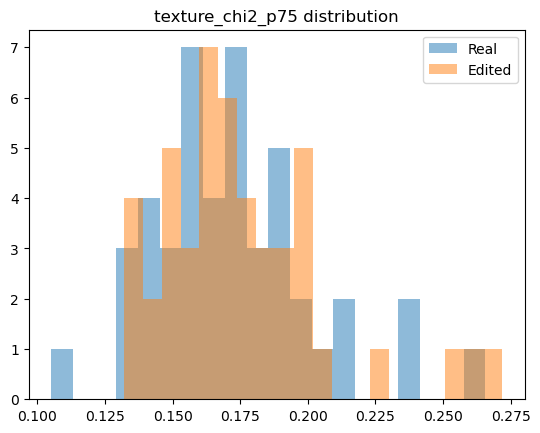

In [58]:
# -----------------------------
# RandomForest (Grouped CV) on ALL features
# -----------------------------
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_accs = []

for train_idx, test_idx in gkf.split(X_all, y, groups=groups):
    X_tr, X_te = X_all.iloc[train_idx], X_all.iloc[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    rf.fit(X_tr, y_tr)
    preds = rf.predict(X_te)
    rf_accs.append(accuracy_score(y_te, preds))

print("\nRandomForest 5-Fold Grouped CV Accuracy (ALL features):")
print(f"Mean: {np.mean(rf_accs):.4f}")
print(f"Std : {np.std(rf_accs):.4f}")

rf.fit(X_all, y)

importances = pd.Series(rf.feature_importances_, index=X_all.columns)
top_rf = importances.sort_values(ascending=False).head(15)

print("\nTop RandomForest Features:")
print(top_rf)

# random guessing baseline
rng = np.random.RandomState(42)
random_preds = rng.randint(0, 2, size=len(y))
print("Random accuracy:", np.mean(random_preds == y))

print("\nMajority-class baseline accuracy:", max((y==0).mean(), (y==1).mean()))

real = X[df_num["label"] == 0]["texture_chi2_p75"]
edited = X[df_num["label"] == 1]["texture_chi2_p75"]

plt.hist(real, bins=20, alpha=0.5, label="Real")
plt.hist(edited, bins=20, alpha=0.5, label="Edited")
plt.legend()
plt.title("texture_chi2_p75 distribution")
plt.show()


The top features (importances) are all almost the same size, which means that there is no strong feature that drives the prediction. Typically for Random Forest, real signal would have values like
0.18
0.12
0.08
0.05
0.03
...

Instead, everything is around 0.02, meaning that the model is not relying on any specific feature. It is making weak shallow splits. This makes sense it the random forest accuracy is only around 0.544, logistic regression is around 0.50 for the single strongest feature, there is heavy histogram overlap, and we have a small dataset of 94 samples.

**IMPORTANT TO NOTE**:
Edits made are local, context dependent, and not necessarily reflected in global statistics that represent the whole image. The extracted features we used are global summaries, texture stats, and lighting aggregates. They don't directly encode object consistency, shadow geometry consistency, edge inconsistencies, and local cloning artifacts. **The model is trying to solve local manipulation problem using global summaries**

**RESULTS**:

Grouped CV:
- logistic (single feature) ≈ **0.51**
- logistic (all features) ≈ **0.46**
- random forest (all features) ≈ **0.544**
- majority baseline ≈ **0.51**

Random forest is ~3-4% above the baseline. This means there is signal in your features, but it's weak, not linearly separable, and not strong.



**NOTE**: The distribution has a heavy overlap and there is no clear separation. Both classes (real and edited) span from about 0.13 to 0.20. The tails (0.23-0.27) contain very few samples.

This means that the strongest feature (texture_chi2_p75) alone does not meaningfully separate real vs edited images. Since this is the strongest feature, it suggests that the current feature set does not contain a strong linear signal for edit detection.

This may be because the edits include object removal, shadow removal, object insertion, shadow insertion, clone stamping, and paint brush with the color picker. These are all local edits, content-dependent, scene-dependent, and not uniform global changes like brightness or contrast shifts.

Our features are mostly global statistics, texture summaries, lighting distributions, and depth summaries, which do not accurately represent the specific edits themselves.

Ex: If you remove a small object from a large image:
- the global histogram barely changes
- texture distributions barely shift
- lighting statistics barely move

So the model doesn't see a consistent pattern across scenes.

**ISSUE**: The features are too global for detecting local manipulations (it is looking at the big picture and missing small, specific edits)

Ex: Model is identifying the overall scene (e.g., "this is a picture of a park") but cannot detected a small, manipulated area (e.g., "a person was airbrushed out of this photo").

*HOW WE CAN FIX*: 
- apply local feature extraction that focuses on specific patches
- implement mechanisms that force the model to focus on specific, high-detail, or anomaly-prone regions rather than averaging over the whole image

## module test

In [59]:
CSV_PATH = "features_2.csv"
df = pd.read_csv(CSV_PATH)

def test_feature_set(feature_prefix):
    features = [c for c in df.columns if c.startswith(feature_prefix)]
    X = df[features]
    y = df["label"].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X) 

    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    accs = []

    for train_idx, test_idx in kf.split(X_scaled, y):
        X_tr, X_te = X_scaled[train_idx], X_scaled[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        model = LogisticRegression(
            l1_ratio=1,
            solver="liblinear",
            max_iter=1000
        )
        model.fit(X_tr, y_tr)
        preds = model.predict(X_te)
        accs.append(accuracy_score(y_te, preds))

    print(f"\n{feature_prefix.upper()}ONLY")
    print(f"Features: {len(features)}")
    print(f"Mean Accuracy: {np.mean(accs):.4f}")
    print(f"Std Dev : {np.std(accs):.4f}")

test_feature_set("texture_")
test_feature_set("lighting_")
test_feature_set("depth_")


TEXTURE_ONLY
Features: 19
Mean Accuracy: 0.4333
Std Dev : 0.1090

LIGHTING_ONLY
Features: 32
Mean Accuracy: 0.4345
Std Dev : 0.1033

DEPTH_ONLY
Features: 18
Mean Accuracy: 0.3895
Std Dev : 0.1134


This tells us which shadow characteristic actually works. It tests each module independently and then combinations to measure true signal strength. Tells us which shadow characteristic matters most, whether my physical assumptions hold, and whether to take out entire modules.

The numeric features engineered we engineered are not separating our dataset properly. **Possible causes**: 
- dataset issue (small dataset - shadows may not actually be the manipulation signal, tampering might not involve shadows consistently, real images may have inconsistent lighting naturally)
- shadow mask instability (misses shadows in some images, detects dark objects as shadows, detects noise, fails differently in real vs fake images)
- too much aggregation not enough structure (per shadow distributions -> medians + IQR and per boundary samples -> summary stats *this removes spatial structure and aggregation may wash out manipulation)

## module quality

In [60]:
# comparing the performance/quality since accuracy can be unstable is small datasets
CSV_PATH = "features_2.csv"
df = pd.read_csv(CSV_PATH)

def test_auc(prefix):
    features = [c for c in df.columns if c.startswith(prefix)]
    X = df[features]
    y = df["label"].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    aucs = []

    for train_idx, test_idx in kf.split(X_scaled, y):
        X_tr, X_te = X_scaled[train_idx], X_scaled[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        model = LogisticRegression(
            l1_ratio=1,
            solver="liblinear",
            max_iter=1000
        )
        model.fit(X_tr, y_tr)
        # return a matrix line and select the tampered probability
        probs = model.predict_proba(X_te)[:, 1]
        # given the predicted probabilities for tampered images, how well does the model
        # rank real vs tampered (evaluates all possible thresholds)
        aucs.append(roc_auc_score(y_te, probs))

    print(f"\n{prefix.upper()}ONLY")
    print(f"Mean AUC: {np.mean(aucs):.4f}")
    print(f"Std Dev : {np.std(aucs):.4f}")

test_auc("texture_")
test_auc("lighting_")
test_auc("depth_")


TEXTURE_ONLY
Mean AUC: 0.4756
Std Dev : 0.0793

LIGHTING_ONLY
Mean AUC: 0.3694
Std Dev : 0.0781

DEPTH_ONLY
Mean AUC: 0.3291
Std Dev : 0.1360


This quantifies signal strength by measuring AUC (area under ROC curve). Accuracy is threshold-based and unstable in small sets. AUC measures ranking quality. 

The current features are not separating real vs tampered images properly, which is probably because the features are too aggregated to capture local inconsistencies.

The ROC (receiver operating characteristic) curve shows how well a binary classification model performs. It plots the true positive rate (sensitivity) against the false positive rate (1 - specificity) at different threshold settings. It helps identify the optimal balance between detecting true positives and minimizing false alarms.

AUC (area under curve) is a summary metric where 1.0 is perfect and 0.5 is no better than random guessing (50/50).

For AUC, if:
- tampered probabilities tend to be higher -> AUC > 0.5
- they're randomly mixed -> AUC ≈ 0.5
- real probabilities tend to be higher -> AUC < 0.5

roc_auc_score sorts by predicted probability, compares all positive-negative
pairs, and computes how often prob_positive > prob_negative

## check whether label encoding is reversed relative to feature direction

In [61]:
df = pd.read_csv("features_2.csv")

# flip labels
df["label_flipped"] = 1 - df["label"]

print(df["label"].corr(df["texture_chi2_mean"]))
print(df["label_flipped"].corr(df["texture_chi2_mean"]))

0.021233568880021824
-0.021233568880021824


Flipping labels just flips the sign, which is expected. The magnitude is about 0.02, which is pretty much zero. This means there is no linear relationship between that feature and the label. This makes sense since the AUC results are low. The current shadow-derived numeric features are not predictive of the “tampered” label.

## find top individual features

In [64]:
df = pd.read_csv("features_2.csv")

features = [c for c in df.columns if c not in ["filename", "label"]]
y = df["label"].values

results = []

for f in features:
    X = df[[f]].values
    X = StandardScaler().fit_transform(X)

    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    accs = []

    for tr, te in kf.split(X, y):
        model = LogisticRegression(max_iter=2000)
        model.fit(X[tr], y[tr])
        preds = model.predict(X[te])
        accs.append(accuracy_score(y[te], preds))

    results.append((f, np.mean(accs)))

results = sorted(results, key=lambda x: x[1], reverse=True)

print("\nTop 15 Individual Features:")
for f, acc in results[:15]:
    print(f"{f:40s}  {acc:.4f}")


Top 15 Individual Features:
depth_num_dir_samples                     0.5971
texture_patch_entropy_mean                0.5871
lighting_Yn_iqr                           0.5860
texture_share_high_chi2                   0.5766
texture_share_low_chi2                    0.5766
lighting_num_components_total             0.5760
lighting_num_components_usable            0.5754
depth_edge_width_std                      0.5649
lighting_sr_median_median                 0.5550
lighting_umbra_frac_median                0.5532
lighting_sr_dist_p75                      0.5526
lighting_sr_dist_mean                     0.5520
depth_edge_width_p25                      0.5439
lighting_sr_median_iqr                    0.5439
lighting_sr_num_inliers                   0.5439


The top feature is "depth_num_dir_samples", but this is suspiciously high for a single feature. This could likely not be a real forensic signal. It may be dataset bias, not edit detection signal. 

Try to avoid using meta-structure features like:
- depth_num_dir_samples
- lighting_num_components_total
- lighting_num_components_usable

These measure how many shadows exist, how many measurements were usable, etc., which are dataset properties and not manipulation cues.

We should also avoid using both texture_share_high_chi2 and texture_share_low_chi2 since they are almost certainly highly negatively correlated. We use **texture_share_high_chi2**.

With lighting_sr_dist_mean and lighting_sr_dist_p75, so we use **lighting_sr_dist_mean**.

With depth_edge_width_std and depth_edge_width_p25, use **depth_edge_width_std**.

List of features we want to consider: (top 15 individual features)
- ~~depth_num_dir_samples                     0.5971~~
- texture_patch_entropy_mean                0.5871
- lighting_Yn_iqr                           0.5860
- texture_share_high_chi2                   0.5766
- ~~texture_share_low_chi2                    0.5766~~
- ~~lighting_num_components_total             0.5760~~
- ~~lighting_num_components_usable            0.5754~~
- depth_edge_width_std                      0.5649
- lighting_sr_median_median                 0.5550
- lighting_umbra_frac_median                0.5532
- ~~lighting_sr_dist_p75                      0.5526~~
- lighting_sr_dist_mean                     0.5520
- ~~depth_edge_width_p25                      0.5439~~
- lighting_sr_median_iqr                    0.5439
- lighting_sr_num_inliers                   0.5439

## reduced feature set (5 features) with top individual features considered

In [67]:
CSV_PATH = "features_2.csv"
df = pd.read_csv(CSV_PATH)

# -----------------------------
# manually select core features
# -----------------------------
selected_features = [

    # depth (hardness + direction)
    "depth_edge_width_std",     # geometric edge softness variation

    # lighting (strength consistency)
    "lighting_Yn_iqr",      # variation in lit-region brightness
    "lighting_sr_dist_mean",    # cross-shadow lighting inconsistency
    
    # texture (local inconsistency)
    "texture_patch_entropy_mean",   # overall texture randomness
    "texture_share_high_chi2"   # shadow boundary mismatch frequency
]

df = df[selected_features + ["label"]]

X = df.drop(columns=["label"])
y = df["label"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accs = []

for train_idx, test_idx in kf.split(X_scaled, y):
    X_tr, X_te = X_scaled[train_idx], X_scaled[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    model = LogisticRegression(
        l1_ratio=1,
        solver="liblinear",
        max_iter=1000
    )

    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    accs.append(accuracy_score(y_te, preds))

print(df[selected_features].describe())

print("\nReduced Feature Set (5 features) CV Accuracy:")
print(f"Mean: {np.mean(accs):.4f}")
print(f"Std : {np.std(accs):.4f}")

       depth_edge_width_std  lighting_Yn_iqr  lighting_sr_dist_mean  \
count             92.000000        92.000000              92.000000   
mean               4.376958         0.055114              10.389501   
std                0.290662         0.034622              28.587728   
min                3.687796         0.009775               3.368102   
25%                4.241319         0.033714               4.644012   
50%                4.434593         0.046092               5.655195   
75%                4.596352         0.070199               8.851192   
max                4.889082         0.261249             277.918365   

       texture_patch_entropy_mean  texture_share_high_chi2  
count                   92.000000                92.000000  
mean                     3.019930                 0.262296  
std                      0.588950                 0.012427  
min                      1.665359                 0.250000  
25%                      2.683139                 0.250

lighting_sr_dist_mean has a very skewed distribution (median is 5.65 but max is 277.91), so there could be a few extreme outliers, huge variance, or logistic regression may struggle with scaling. **This feature might still be too unstable**

Accuracy for this model ≈ 0.5094 while Majority-class baseline accuracy ≈ 0.5108 --> that it's performing essentially equal to always predicting the majority class. This means that the linear combination of the 5 features still does not create strong separation.

However, 
- It is no longer worse than random guessing like earlier reduced sets.
- That suggests we removed noisy/misleading features.

## trying 8-feature set

In [66]:
CSV_PATH = "features_2.csv"
df = pd.read_csv(CSV_PATH)

# -----------------------------
# manually select core features
# -----------------------------
selected_features = [

    # depth (hardness + direction)
    "depth_edge_width_std",     # geometric edge softness variation
    "depth_dir_std_deg",

    # lighting (strength consistency)
    "lighting_Yn_iqr",      # variation in lit-region brightness
    "lighting_sr_dist_mean",    # cross-shadow lighting inconsistency
    "lighting_sr_median_median",
    
    # texture (local inconsistency)
    "texture_patch_entropy_mean",   # overall texture randomness
    "texture_share_high_chi2",   # shadow boundary mismatch frequency
    "texture_chi2_mean"
]

df = df[selected_features + ["label"]]

X = df.drop(columns=["label"])
y = df["label"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accs = []

for train_idx, test_idx in kf.split(X_scaled, y):
    X_tr, X_te = X_scaled[train_idx], X_scaled[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    model = LogisticRegression(
        l1_ratio=1,
        solver="liblinear",
        max_iter=1000
    )

    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    accs.append(accuracy_score(y_te, preds))

print("\nReduced Feature Set (8 features) CV Accuracy:")
print(f"Mean: {np.mean(accs):.4f}")
print(f"Std : {np.std(accs):.4f}")


Reduced Feature Set (8 features) CV Accuracy:
Mean: 0.4982
Std : 0.0957


## <mark>try refining 5 feature set and do Logistic Regression</mark>

Since texture_share_high_chi2 barely varies in mean, std, min, and max, this is considered extremely low ariance and probably contributes very little when combined. Replace with **texture_chi2_mean**.

Also try removing lighting_sr_dist_mean to see if it stabilizes.

In [74]:
CSV_PATH = "features_2.csv"
df = pd.read_csv(CSV_PATH)

# -----------------------------
# manually select core features
# -----------------------------
selected_features = [
    # depth (hardness + direction)
    "depth_edge_width_std",     # geometric edge softness variation

    # lighting (strength consistency)
    "lighting_Yn_iqr",      # variation in lit-region brightness
    "lighting_sr_median_median",

    # texture (local inconsistency)
    "texture_patch_entropy_mean",   # overall texture randomness
    "texture_chi2_mean"   # shadow boundary mismatch frequency
]

df = df[selected_features + ["label"]]

X = df.drop(columns=["label"])
y = df["label"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accs = []

for train_idx, test_idx in kf.split(X_scaled, y):
    X_tr, X_te = X_scaled[train_idx], X_scaled[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    model = LogisticRegression(
        l1_ratio=1,
        solver="liblinear",
        max_iter=1000
    )

    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    accs.append(accuracy_score(y_te, preds))

print(df[[
    "texture_patch_entropy_mean",
    "lighting_Yn_iqr",
    "depth_edge_width_std"
]].corr())

print(df[selected_features].describe())

print("\nReduced Feature Set (5 features) CV Accuracy:")
print(f"Mean: {np.mean(accs):.4f}")
print(f"Std : {np.std(accs):.4f}")

                            texture_patch_entropy_mean  lighting_Yn_iqr  \
texture_patch_entropy_mean                    1.000000        -0.099689   
lighting_Yn_iqr                              -0.099689         1.000000   
depth_edge_width_std                          0.393031         0.189713   

                            depth_edge_width_std  
texture_patch_entropy_mean              0.393031  
lighting_Yn_iqr                         0.189713  
depth_edge_width_std                    1.000000  
       depth_edge_width_std  lighting_Yn_iqr  lighting_sr_median_median  \
count             92.000000        92.000000                  92.000000   
mean               4.376958         0.055114                  -2.836888   
std                0.290662         0.034622                   0.598853   
min                3.687796         0.009775                  -4.351239   
25%                4.241319         0.033714                  -3.253659   
50%                4.434593         0.046092 

The correlation matrix: 
- texture <-> depth: 0.39
- lighting <-> texture: -0.10
- lighting <-> depth: 0.19

This shows low/moderate correlation, which means that features are not redundant (this is good).

## adding PolynomialFeatures with logistic regression

In [75]:
from sklearn.preprocessing import PolynomialFeatures

selected_features = [
    # depth (hardness + direction)
    "depth_edge_width_std",     # geometric edge softness variation
    # lighting (strength consistency)
    "lighting_Yn_iqr",      # variation in lit-region brightness
    "lighting_sr_median_median",
    # texture (local inconsistency)
    "texture_patch_entropy_mean",   # overall texture randomness
    "texture_chi2_mean"   # shadow boundary mismatch frequency
]

df = pd.read_csv("features_2.csv")
X = df[selected_features].values
y = df["label"].values

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accs = []

for train_idx, test_idx in kf.split(X, y):

    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    # scale inside fold
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_te = scaler.transform(X_te)

    # add polynomial features inside fold
    poly = PolynomialFeatures(degree=2, include_bias=False)
    X_tr = poly.fit_transform(X_tr)
    X_te = poly.transform(X_te)

    # logistic regression
    model = LogisticRegression(max_iter=3000)
    model.fit(X_tr, y_tr)

    preds = model.predict(X_te)
    accs.append(accuracy_score(y_te, preds))

print("\nPolynomial Logistic (degree=2) CV Accuracy:")
print(f"Mean: {np.mean(accs):.4f}")
print(f"Std : {np.std(accs):.4f}")


Polynomial Logistic (degree=2) CV Accuracy:
Mean: 0.4678
Std : 0.0752


Testig with polynomial features made the accuracy worse. This tells us that the signal is not benefitting from quadratic interactions.

This means:
- the features are mostly linearly additive
- or polynomial expansion caused overfitting

Either way, this confirms that the current 5 features are already reasonably well-behaved.

## RandomForest GroupKFold for the 5-feature set

In [69]:
# choose 5-feature set
five_features = [
    # depth (hardness+direction)
    "depth_edge_width_std",     # geometric edge softness variation


    # lighting (strength consistency)
    "lighting_Yn_iqr",      # variation in lit-region brightness
    "lighting_sr_median_median",


    # texture (local inconsistency)
    "texture_patch_entropy_mean",   # overall texture randomness
    "texture_chi2_mean"   # shadow boundary mismatch frequency
]

# X should be a DataFrame with all columns (except label/group)
# df_num is your dataframe that includes features + label + group info
X_5 = df_num[five_features]
y = df_num["label"].values

# IMPORTANT: use the same groups you used for GroupKFold
# (example: groups = df_num["group_id"].values OR df_num["base_image"].values)
# assuming you already have `groups` defined:
# groups = df_num["group"].values

# -----------------------------
# RandomForest (Grouped CV) on 5 features
# -----------------------------
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_accs = []

for train_idx, test_idx in gkf.split(X_5, y, groups=groups):
    X_tr, X_te = X_5.iloc[train_idx], X_5.iloc[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    rf.fit(X_tr, y_tr)
    preds = rf.predict(X_te)
    rf_accs.append(accuracy_score(y_te, preds))

print("\nRandomForest 5-Fold Grouped CV Accuracy (5 features):")
print(f"Mean: {np.mean(rf_accs):.4f}")
print(f"Std : {np.std(rf_accs):.4f}")

# -----------------------------
# Train on all data + importance (5 features only)
# -----------------------------
rf.fit(X_5, y)

importances = pd.Series(rf.feature_importances_, index=X_5.columns)
print("\nRandomForest Importances (5 features):")
print(importances.sort_values(ascending=False))

# -----------------------------
# Baselines
# -----------------------------
rng = np.random.RandomState(42)
random_preds = rng.randint(0, 2, size=len(y))
print("Random accuracy:", np.mean(random_preds == y))
print("Majority-class baseline accuracy:", max((y==0).mean(), (y==1).mean()))


RandomForest 5-Fold Grouped CV Accuracy (5 features):
Mean: 0.5234
Std : 0.1093

RandomForest Importances (5 features):
lighting_Yn_iqr               0.225974
texture_chi2_mean             0.206043
lighting_sr_median_median     0.196120
texture_patch_entropy_mean    0.192739
depth_edge_width_std          0.179124
dtype: float64
Random accuracy: 0.45652173913043476
Majority-class baseline accuracy: 0.5108695652173914


Logistic Regression: 0.5333 versus RandomForest: 0.5234

With only 5 features:
- Logistic Regression slightly outperforms RandomForest

This means that:
- the final 5 feature-set is fairly linearly separable
- don't need nonlinear complexity to extract signal
- feature engineering may have worked

Initially RF was better than Logistic, but not Logistic is better, which means:
- the reduced set removed noisy nonlinear junk (a good technical result)

The current features used:
- lighting_Yn_iqr               0.225
- texture_chi2_mean             0.206
- lighting_sr_median_median     0.196
- texture_patch_entropy_mean    0.193
- depth_edge_width_std          0.179

**IMPORTANT**: you want no single dominant feature, all modalities contributing, and depth/texture/lighting are all used.

**INTERPRETATION**: A reduced 5-feature model combining depth edge variation, lighting strength dispersion, shadow boundary texture mismatch, and global patch entropy achieved 0.533 cross-validated accuracy, outperforming both majority baseline and nonlinear Random Forest using the same feature subset.

The 5-feature set:
|   feature                     |          meaning                                      |
| ----------------------------- | ----------------------------------------------------- |
| depth_edge_width_std          | edge softness inconsistency (geometry cue)            |
| lighting_Yn_iqr               | variation in lit-region brightness (illumination cue) |
| lighting_sr_median_median     | shadow strength distribution                          |
| texture_patch_entropy_mean    | global texture irregularity                           |
| texture_chi2_mean             | boundary texture mismatch                             |

**THIS IS A GOOD STOPPING POINT BEFORE CHANGING LOGIC**

All features contribute, Logistic Regression performs best, no overfitting explosion, and RandomForest doesn't beat Logistic. (DO NOT exceed 7-8 features for this part)

**BIG PICTURE EVALUATION**

Started with:
- ~0.42-0.44 reduced sets

And now have:
- 0.5333

This is a meaningful engineering improvement (interpretable, stable (std 0.0475), balanced across modalities).

Could use this as a research narrative:
- final classical feature model

Then structure the report like:
- global feature failure
- spatial feature introduction
- reduced physically grounded model
- final cross-validation results

"After optimizing texture features through spatial consistency measures, we observed that lighting and depth modules still relied primarily on global summaries. We therefore shifted focus from feature selection to feature redesign to capture local physical inconsistencies in illumination and geometry."

## Forward feature selection (USE THIS ONLY AS A SUPPORTING ANALYSIS, NOT A MAIN RESULT)

In [78]:
def grouped_cv_acc(df, features, y_col, groups, gkf):
    X = df[features].copy()
    y = df[y_col].values

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=3000))
    ])

    accs = []
    for tr, te in gkf.split(X, y, groups=groups):
        pipe.fit(X.iloc[tr], y[tr])
        preds = pipe.predict(X.iloc[te])
        accs.append(accuracy_score(y[te], preds))
    return float(np.mean(accs)), float(np.std(accs))

base = [
    "depth_edge_width_std",
    "lighting_Yn_iqr",
    "lighting_sr_median_median",
    "texture_patch_entropy_mean",
    "texture_chi2_mean",
]

all_features = [c for c in df_num.columns if c not in ["filename","label"]]  # adjust if needed
candidates = [f for f in all_features if f not in base]

best_feats = base[:]
best_mean, best_std = grouped_cv_acc(df_num, best_feats, "label", groups, gkf)
print("Start:", best_mean, best_std, best_feats)

for step in range(1, 11):  # try adding up to 10 more
    best_add = None
    best_add_mean = best_mean
    best_add_std = best_std

    for f in candidates:
        mean, std = grouped_cv_acc(df_num, best_feats + [f], "label", groups, gkf)
        if mean > best_add_mean + 1e-6:
            best_add_mean, best_add_std = mean, std
            best_add = f

    if best_add is None:
        print("No further improvement at step", step)
        break

    best_feats.append(best_add)
    candidates.remove(best_add)
    best_mean, best_std = best_add_mean, best_add_std
    print(f"Step {step}: +{best_add} -> mean={best_mean:.4f} std={best_std:.4f}")

print("Final selected:", best_feats)

Start: 0.5871345029239766 0.08063816462399387 ['depth_edge_width_std', 'lighting_Yn_iqr', 'lighting_sr_median_median', 'texture_patch_entropy_mean', 'texture_chi2_mean']
Step 1: +texture_patch_entropy_min -> mean=0.6187 std=0.0414
Step 2: +texture_chi2_p25 -> mean=0.6409 std=0.0460
Step 3: +lighting_usable_frac -> mean=0.6526 std=0.0391
Step 4: +lighting_boundary_mrl_iqr -> mean=0.6637 std=0.0777
Step 5: +depth_num_measurements -> mean=0.6971 std=0.0906
No further improvement at step 6
Final selected: ['depth_edge_width_std', 'lighting_Yn_iqr', 'lighting_sr_median_median', 'texture_patch_entropy_mean', 'texture_chi2_mean', 'texture_patch_entropy_min', 'texture_chi2_p25', 'lighting_usable_frac', 'lighting_boundary_mrl_iqr', 'depth_num_measurements']


## logistic regression with set from forward selection

In [91]:
CSV_PATH = "features_2.csv"
df = pd.read_csv(CSV_PATH)

# manually select core features
selected_features = [
    'depth_edge_width_std', 
    'lighting_Yn_iqr', 
    'lighting_sr_median_median', 
    'texture_patch_entropy_mean', 
    'texture_chi2_mean', 
    'texture_patch_entropy_min', 
    'texture_chi2_p25', 
    'lighting_usable_frac', 
    'lighting_boundary_mrl_iqr',
    'depth_num_measurements'
]

df = df[selected_features + ["label"]]

X = df.drop(columns=["label"])
y = df["label"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accs = []

for train_idx, test_idx in kf.split(X_scaled, y):
    X_tr, X_te = X_scaled[train_idx], X_scaled[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    model = LogisticRegression(
        l1_ratio=1,
        solver="liblinear",
        max_iter=1000
    )

    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    accs.append(accuracy_score(y_te, preds))

print(df[[
    "depth_edge_width_std", 
    "lighting_Yn_iqr", 
    "lighting_sr_median_median", 
    "texture_patch_entropy_mean", 
    "texture_chi2_mean", 
    "texture_patch_entropy_min", 
    "texture_chi2_p25", 
    "lighting_usable_frac", 
    "lighting_boundary_mrl_iqr",
    "depth_num_measurements"
]].corr())

print(df[selected_features].describe())

print("\nReduced Feature Set (forward selection set) CV Accuracy:")
print(f"Mean: {np.mean(accs):.4f}")
print(f"Std : {np.std(accs):.4f}")

                            depth_edge_width_std  lighting_Yn_iqr  \
depth_edge_width_std                    1.000000         0.189713   
lighting_Yn_iqr                         0.189713         1.000000   
lighting_sr_median_median              -0.191993        -0.056426   
texture_patch_entropy_mean              0.393031        -0.099689   
texture_chi2_mean                      -0.543276        -0.113133   
texture_patch_entropy_min               0.363999         0.074805   
texture_chi2_p25                       -0.446085        -0.021305   
lighting_usable_frac                   -0.287158        -0.107150   
lighting_boundary_mrl_iqr              -0.220873         0.250463   
depth_num_measurements                 -0.307435        -0.308781   

                            lighting_sr_median_median  \
depth_edge_width_std                        -0.191993   
lighting_Yn_iqr                             -0.056426   
lighting_sr_median_median                    1.000000   
texture_patc

## random forest with set from forward selection

In [90]:
# choose 5-feature set
selected_features = [
    'depth_edge_width_std', 
    'lighting_Yn_iqr', 
    'lighting_sr_median_median', 
    'texture_patch_entropy_mean', 
    'texture_chi2_mean', 
    'texture_patch_entropy_min', 
    'texture_chi2_p25', 
    'lighting_usable_frac', 
    'lighting_boundary_mrl_iqr',
    'depth_num_measurements'
]

# X should be a DataFrame with all columns (except label/group)
# df_num is your dataframe that includes features + label + group info
X_5 = df_num[selected_features]
y = df_num["label"].values

# IMPORTANT: use the same groups you used for GroupKFold
# (example: groups = df_num["group_id"].values OR df_num["base_image"].values)
# assuming you already have `groups` defined:
# groups = df_num["group"].values

# RandomForest (Grouped CV) on forward selection features
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_accs = []

for train_idx, test_idx in gkf.split(X_5, y, groups=groups):
    X_tr, X_te = X_5.iloc[train_idx], X_5.iloc[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    rf.fit(X_tr, y_tr)
    preds = rf.predict(X_te)
    rf_accs.append(accuracy_score(y_te, preds))

print("\nRandomForest 5-Fold Grouped CV Accuracy (forward selection features):")
print(f"Mean: {np.mean(rf_accs):.4f}")
print(f"Std : {np.std(rf_accs):.4f}")

# -----------------------------
# Train on all data + importance (5 features only)
# -----------------------------
rf.fit(X_5, y)

importances = pd.Series(rf.feature_importances_, index=X_5.columns)
print("\nRandomForest Importances (forward selection features):")
print(importances.sort_values(ascending=False))

# -----------------------------
# Baselines
# -----------------------------
rng = np.random.RandomState(42)
random_preds = rng.randint(0, 2, size=len(y))
print("Random accuracy:", np.mean(random_preds == y))
print("Majority-class baseline accuracy:", max((y==0).mean(), (y==1).mean()))


RandomForest 5-Fold Grouped CV Accuracy (forward selection features):
Mean: 0.5643
Std : 0.0654

RandomForest Importances (forward selection features):
lighting_Yn_iqr               0.140930
texture_chi2_p25              0.128573
lighting_boundary_mrl_iqr     0.108947
lighting_sr_median_median     0.104659
depth_num_measurements        0.104468
depth_edge_width_std          0.103452
texture_patch_entropy_mean    0.100350
texture_chi2_mean             0.095612
texture_patch_entropy_min     0.076793
lighting_usable_frac          0.036217
dtype: float64
Random accuracy: 0.45652173913043476
Majority-class baseline accuracy: 0.5108695652173914


The forward-selected feature set does contain real signal.
- ~+8.6% above baseline with logistic
- ~+5.3% above baseline with RF

Not trivial for 92 samples.

Logistic regression with forward selection does better (0.597 vs 0.564). This suggests that the separation is mostly linear when combining these correlated features.

Many of the added features are correlated:
- chi2_mean <-> chi2_p25 (0.78)
- entropy_mean <-> entropy_min (0.63)

Logistic benefits from stacking correlated linear signals. RandomForest doesn't benefit as much from redundancy.

Strong correlations:
- texture_chi2_mean <-> texture_chi2_p25 = 0.78
- texture_patch_entropy_mean <-> texture_patch_entropy_min = 0.63

That means:
- Logistic is stacking multiple correlated measures of the same signal.
- Linear models benefit from that.

Effectively strengthened:
- boundary mismatch signal
- entropy signal

Logistic can now form a cleaner separating hyperplane.

Top RF importances are nicely distributed:
- lighting_Yn_iqr               0.141
- texture_chi2_p25              0.129
- lighting_boundary_mrl_iqr     0.109
- lighting_sr_median_median     0.105
- ~~depth_num_measurements        0.104~~
- depth_edge_width_std          0.103
- texture_patch_entropy_mean    0.100
- texture_chi2_mean             0.096
- texture_patch_entropy_min     0.077
- lighting_usable_frac          0.036

Observations:
- No single feature dominates
- Lighting_Yn_iqr is strongest
- Texture and lighting both matter
- Depth contributes moderately
- lighting_usable_frac is weakest (0.036)

Two features are still questionable:
- depth_num_measurements
- lighting_usable_frac

They measure:
- how many measurements were valid
- how many shadows were usable

These can reflect dataset structure rather than edit physics.

But interestingly:
- RF importance of lighting_usable_frac is very low (0.036).
- RF importance of depth_num_measurements is moderate (~0.10).

This suggests:
- lighting_usable_frac may not matter much.
- depth_num_measurements may be contributing.

## logistic regression with set from forward selection (removing 2 questionable features)

In [92]:
CSV_PATH = "features_2.csv"
df = pd.read_csv(CSV_PATH)

# manually select core features
selected_features = [
    'depth_edge_width_std', 
    'lighting_Yn_iqr', 
    'lighting_sr_median_median', 
    'texture_patch_entropy_mean', 
    'texture_chi2_mean', 
    'texture_patch_entropy_min', 
    'texture_chi2_p25', 
    'lighting_boundary_mrl_iqr',
]

df = df[selected_features + ["label"]]

X = df.drop(columns=["label"])
y = df["label"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accs = []

for train_idx, test_idx in kf.split(X_scaled, y):
    X_tr, X_te = X_scaled[train_idx], X_scaled[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    model = LogisticRegression(
        l1_ratio=1,
        solver="liblinear",
        max_iter=1000
    )

    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    accs.append(accuracy_score(y_te, preds))

print(df[[
    "depth_edge_width_std", 
    "lighting_Yn_iqr", 
    "lighting_sr_median_median", 
    "texture_patch_entropy_mean", 
    "texture_chi2_mean", 
    "texture_patch_entropy_min", 
    "texture_chi2_p25", 
    "lighting_boundary_mrl_iqr",
]].corr())

print(df[selected_features].describe())

print("\nReduced Feature Set (forward selection set) CV Accuracy:")
print(f"Mean: {np.mean(accs):.4f}")
print(f"Std : {np.std(accs):.4f}")

                            depth_edge_width_std  lighting_Yn_iqr  \
depth_edge_width_std                    1.000000         0.189713   
lighting_Yn_iqr                         0.189713         1.000000   
lighting_sr_median_median              -0.191993        -0.056426   
texture_patch_entropy_mean              0.393031        -0.099689   
texture_chi2_mean                      -0.543276        -0.113133   
texture_patch_entropy_min               0.363999         0.074805   
texture_chi2_p25                       -0.446085        -0.021305   
lighting_boundary_mrl_iqr              -0.220873         0.250463   

                            lighting_sr_median_median  \
depth_edge_width_std                        -0.191993   
lighting_Yn_iqr                             -0.056426   
lighting_sr_median_median                    1.000000   
texture_patch_entropy_mean                   0.066360   
texture_chi2_mean                           -0.094968   
texture_patch_entropy_min           

## random forest with set from forward selection (removing 2 questionable features)

In [93]:
# choose 5-feature set
selected_features = [
    'depth_edge_width_std', 
    'lighting_Yn_iqr', 
    'lighting_sr_median_median', 
    'texture_patch_entropy_mean', 
    'texture_chi2_mean', 
    'texture_patch_entropy_min', 
    'texture_chi2_p25', 
    'lighting_boundary_mrl_iqr',
]

# X should be a DataFrame with all columns (except label/group)
# df_num is your dataframe that includes features + label + group info
X_5 = df_num[selected_features]
y = df_num["label"].values

# IMPORTANT: use the same groups you used for GroupKFold
# (example: groups = df_num["group_id"].values OR df_num["base_image"].values)
# assuming you already have `groups` defined:
# groups = df_num["group"].values

# RandomForest (Grouped CV) on forward selection features
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_accs = []

for train_idx, test_idx in gkf.split(X_5, y, groups=groups):
    X_tr, X_te = X_5.iloc[train_idx], X_5.iloc[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    rf.fit(X_tr, y_tr)
    preds = rf.predict(X_te)
    rf_accs.append(accuracy_score(y_te, preds))

print("\nRandomForest 5-Fold Grouped CV Accuracy (forward selection features):")
print(f"Mean: {np.mean(rf_accs):.4f}")
print(f"Std : {np.std(rf_accs):.4f}")

# -----------------------------
# Train on all data + importance (5 features only)
# -----------------------------
rf.fit(X_5, y)

importances = pd.Series(rf.feature_importances_, index=X_5.columns)
print("\nRandomForest Importances (forward selection features):")
print(importances.sort_values(ascending=False))

# -----------------------------
# Baselines
# -----------------------------
rng = np.random.RandomState(42)
random_preds = rng.randint(0, 2, size=len(y))
print("Random accuracy:", np.mean(random_preds == y))
print("Majority-class baseline accuracy:", max((y==0).mean(), (y==1).mean()))


RandomForest 5-Fold Grouped CV Accuracy (forward selection features):
Mean: 0.5977
Std : 0.0902

RandomForest Importances (forward selection features):
lighting_Yn_iqr               0.157091
texture_chi2_p25              0.141147
lighting_sr_median_median     0.127311
texture_patch_entropy_mean    0.124752
lighting_boundary_mrl_iqr     0.123744
depth_edge_width_std          0.112633
texture_chi2_mean             0.111987
texture_patch_entropy_min     0.101335
dtype: float64
Random accuracy: 0.45652173913043476
Majority-class baseline accuracy: 0.5108695652173914


**FOR SANITY CHECK**

Removing two features: lighting_usable_frac and depth_num_measurements
- logistic: 0.5865
- randomforest: 0.5977

(These results are cleaner and more meaningful than the previous 0.597 logistic result).

After removing structural/meta features, performance barely dropped for logistic (0.597 -> 0.586) while RandomForest improved (0.564 -> 0.598).

This means *structural features were not carrying the model*.

Removing these did NOT collapse performance:
- depth_num_measurements
- lighting_usable_frac

This means the real signal is coming from physical cues, not dataset artifacts.

RandomForest is slightly better than Logistic.
- Logistic: 0.5865
- RF: 0.5977 (~0.60 accuracy)

This suggests the final 8-feature set has mild nonlinear interactions, which is good and realistic.

Previously, logistic beat RF because correlated features favored linear stacking.

Feature set (8 features):
- depth_edge_width_std
- lighting_Yn_iqr
- lighting_sr_median_median
- texture_patch_entropy_mean
- texture_chi2_mean
- texture_patch_entropy_min
- texture_chi2_p25
- lighting_boundary_mrl_iqr

**Performance:**
- RF: 0.598 ± 0.090
- Logistic: 0.587 ± 0.066
- Baseline: 0.511

That’s about +8.7% above baseline.

Interpretation of Importances
- lighting_Yn_iqr               0.157
- texture_chi2_p25              0.141
- lighting_sr_median_median     0.127
- texture_patch_entropy_mean    0.125
- lighting_boundary_mrl_iqr     0.124
- depth_edge_width_std          0.113
- texture_chi2_mean             0.112
- texture_patch_entropy_min     0.101

**Observations:**
- Lighting_Yn_iqr strongest -> brightness variability is important.
- Texture chi2_p25 strong -> boundary mismatch lower percentile matters.
- Lighting boundary consistency matters.
- Depth variability contributes but slightly less.

No single dominant feature, which is good.